# Data Retrieval — Media Cloud

| Field | Details |
|---|---|
| **Time window** | 5 Jul 2024 – 4 Nov 2024 |
| **Source** | Media Cloud API — `mediacloud` Python client |
| **Method** | API — daily story counts per outlet + full story metadata |
| **Outlets** | CNN · Fox News · NYT · Washington Post · Breitbart · Guardian · NBC · ABC (+ more) |
| **Volume** | **235,191** story records · **123** daily aggregate rows |
| **Saved to** | `Data/1_Bronze/Newspapers/mediacloud_daily.csv` · `mediacloud_stories.csv` · `mediacloud_features.csv` |

### mediacloud_daily.csv — 123 rows × 18 columns

| Column | Description |
|---|---|
| `date` | Date |
| `trump`, `harris`, `election` | Raw daily story counts per search query |
| `trump_pct`, `harris_pct`, `election_pct` | Share of total coverage (%) |
| `trump_share` | Trump stories as % of (Trump + Harris) coverage |
| `total_coverage` | Total story count across all queries |
| `log_trump`, `log_harris`, `log_election`, `log_total_coverage` | Log-transformed counts |
| `trump_7d`, `harris_7d`, `election_7d`, `trump_share_7d`, `total_coverage_7d` | 7-day rolling averages |

### mediacloud_stories.csv — 235,191 rows × 6 columns

| Column | Description |
|---|---|
| `date` | Publication date |
| `query` | Search query used to retrieve the story |
| `title` | Article headline |
| `url` | Full article URL |
| `source` | Media outlet name |
| `pub_date` | Full publication datetime |


In [6]:
import datetime as dt
import time
import os
import pandas as pd
import numpy as np
import mediacloud.api

# ── API Key ─────────────────────────────────────────────────────────────────────
# Plak hier alleen de key zelf (zonder "MC_API_KEY=" prefix)
MC_API_KEY = os.getenv("MC_API_KEY", "19e0165245bd1dfe3772cc9f65d3085a5614bd95")

# ── Date range ──────────────────────────────────────────────────────────────────
START_DATE = dt.date(2024, 7, 5)
END_DATE   = dt.date(2024, 11, 4)

# ── Media collection ────────────────────────────────────────────────────────────
# 34412234 = "U.S. Top Online News" in de nieuwe Media Cloud infrastructuur
US_NATIONAL_COLLECTION = [34412234]

# ── Zoekopdrachten ──────────────────────────────────────────────────────────────
QUERIES = {
    "trump":    '"Trump" AND (election OR president OR campaign OR vote)',
    "harris":   '"Harris" AND (election OR president OR campaign OR vote)',
    "election": '"presidential election" AND 2024',
}

mc = mediacloud.api.SearchApi(MC_API_KEY)
print(f"Period : {START_DATE} → {END_DATE}  ({(END_DATE - START_DATE).days + 1} days)")
print(f"Queries: {list(QUERIES.keys())}")

Period : 2024-07-05 → 2024-11-04  (123 days)
Queries: ['trump', 'harris', 'election']


In [7]:
# ── Connectiviteitstest ──────────────────────────────────────────────────────────
# Stap 1: test zonder collection_ids (enkel API key validatie)
import requests

test_params = {
    "q": "Trump",
    "start": "2024-11-01",
    "end": "2024-11-04",
    "platform": "onlinenews-mediacloud",
}
headers = {"Authorization": f"Token {MC_API_KEY}"}

r = requests.get(
    "https://search.mediacloud.org/api/2/story/count",
    params=test_params,
    headers=headers,
)
print(f"Status: {r.status_code}")
print(r.text[:500])

Status: 200
<!DOCTYPE html>
<html lang="en">

    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <meta http-equiv="X-UA-Compatible" content="ie=edge">
        <link rel="icon" href="../static/img/favicon.ico"> 
        <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/css/bootstrap.min.css" rel="stylesheet" integrity="sha384-Zenh87qX5JnK2Jl0vWa8Ck2rdkQ2Bzep5IDxbcnCeuOxjzrPF/et3URy9Bv1WTRi" crossorigin="anonymous">
 


## 1. Dagelijkse tellingen ophalen

`story_count_over_time` geeft een tijdreeks terug met één datapunt per dag.

In [8]:
def fetch_daily_counts(query: str, label: str) -> pd.DataFrame:
    """Haal dagelijkse artikeltelling op voor één zoekopdracht."""
    print(f"  Fetching '{label}' ...", end=" ", flush=True)
    results = mc.story_count_over_time(
        query,
        START_DATE,
        END_DATE,
        collection_ids=US_NATIONAL_COLLECTION,
    )
    df = pd.DataFrame(results)
    # Kolommen in resultaat: date, count, total_count, ratio
    df["date"] = pd.to_datetime(df["date"]).dt.date
    df = df.rename(columns={"count": label, "ratio": f"{label}_pct"})
    df = df[["date", label, f"{label}_pct"]]
    print(f"{len(df)} rows")
    time.sleep(1)  # beleefd voor de API
    return df

print("Fetching daily counts from Media Cloud ...")
dfs = [fetch_daily_counts(q, lbl) for lbl, q in QUERIES.items()]

# Merge alle queries op datum
daily = dfs[0]
for df in dfs[1:]:
    daily = daily.merge(df, on="date", how="outer")

daily = (
    daily
    .sort_values("date")
    .reset_index(drop=True)
)

# Beperk tot exacte periode
daily = daily[(daily["date"] >= START_DATE) & (daily["date"] <= END_DATE)].copy()

print(f"\nShape: {daily.shape}")
daily.head(10)

Fetching daily counts from Media Cloud ...
  Fetching 'trump' ... 123 rows
  Fetching 'harris' ... 123 rows
  Fetching 'election' ... 123 rows

Shape: (123, 7)


,date,trump,trump_pct,harris,harris_pct,election,election_pct
0,2024-07-05,851,0.123566,259,0.037607,71,0.010309
1,2024-07-06,456,0.110976,110,0.026771,38,0.009248
2,2024-07-07,421,0.106907,191,0.048502,26,0.006602
3,2024-07-08,921,0.119100,265,0.034269,64,0.008276
4,2024-07-09,1070,0.124505,293,0.034094,85,0.009891
5,2024-07-10,1131,0.117837,288,0.030006,98,0.010210
6,2024-07-11,1201,0.134868,371,0.041662,96,0.010780
7,2024-07-12,1042,0.122718,395,0.046520,80,0.009422
8,2024-07-13,1030,0.221267,168,0.036090,74,0.015897
9,2024-07-14,1592,0.323118,172,0.034910,63,0.012787


## 2. Feature engineering

In [9]:
# Relatieve media-aandacht Trump vs Harris
daily["trump_share"] = (
    daily["trump"] / (daily["trump"] + daily["harris"]).replace(0, np.nan)
)

# Totale verkiezingsdekking
daily["total_coverage"] = daily["trump"] + daily["harris"] + daily["election"]

# Log-transformaties (helpt bij scheef verdeelde teldata)
for col in ["trump", "harris", "election", "total_coverage"]:
    daily[f"log_{col}"] = np.log1p(daily[col])

# Rollend 7-daags gemiddelde
for col in ["trump", "harris", "election", "trump_share", "total_coverage"]:
    daily[f"{col}_7d"] = daily[col].rolling(7, min_periods=1).mean()

print("Features:", daily.columns.tolist())
daily.head()

Features: ['date', 'trump', 'trump_pct', 'harris', 'harris_pct', 'election', 'election_pct', 'trump_share', 'total_coverage', 'log_trump', 'log_harris', 'log_election', 'log_total_coverage', 'trump_7d', 'harris_7d', 'election_7d', 'trump_share_7d', 'total_coverage_7d']


,date,trump,trump_pct,harris,harris_pct,election,election_pct,trump_share,total_coverage,log_trump,log_harris,log_election,log_total_coverage,trump_7d,harris_7d,election_7d,trump_share_7d,total_coverage_7d
0,2024-07-05,851,0.123566,259,0.037607,71,0.010309,0.766667,1181,6.747587,5.560682,4.276666,7.074963,851.00,259.000000,71.00,0.766667,1181.000000
1,2024-07-06,456,0.110976,110,0.026771,38,0.009248,0.805654,604,6.124683,4.709530,3.663562,6.405228,653.50,184.500000,54.50,0.786160,892.500000
2,2024-07-07,421,0.106907,191,0.048502,26,0.006602,0.687908,638,6.045005,5.257495,3.295837,6.459904,576.00,186.666667,45.00,0.753410,807.666667
3,2024-07-08,921,0.119100,265,0.034269,64,0.008276,0.776560,1250,6.826545,5.583496,4.174387,7.131699,662.25,206.250000,49.75,0.759197,918.250000
4,2024-07-09,1070,0.124505,293,0.034094,85,0.009891,0.785033,1448,6.976348,5.683580,4.454347,7.278629,743.80,223.600000,56.80,0.764364,1024.200000


## 3. Visualisatie

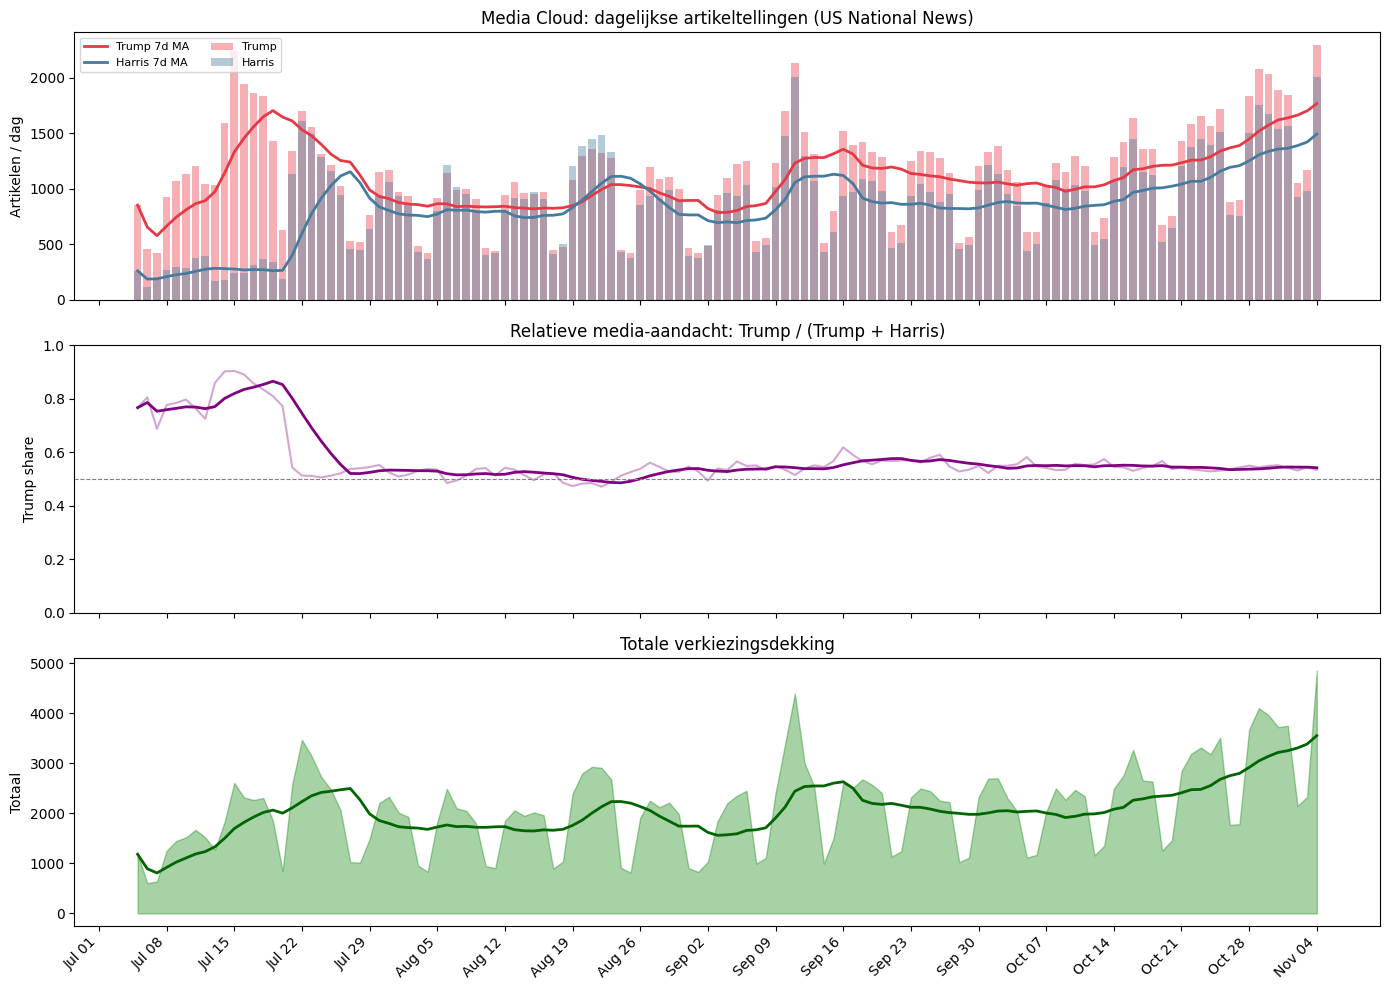

Plot opgeslagen → data/mediacloud_daily_coverage.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
dates = pd.to_datetime(daily["date"])

# Panel 1: absolute tellingen
axes[0].bar(dates, daily["trump"],  color="#e63946", alpha=0.4, label="Trump")
axes[0].bar(dates, daily["harris"], color="#457b9d", alpha=0.4, label="Harris", bottom=0)
axes[0].plot(dates, daily["trump_7d"],  color="#e63946", linewidth=2, label="Trump 7d MA")
axes[0].plot(dates, daily["harris_7d"], color="#457b9d", linewidth=2, label="Harris 7d MA")
axes[0].set_ylabel("Articles / day")
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_title("Media Cloud: daily article counts (US National News)")

# Panel 2: Trump share
axes[1].plot(dates, daily["trump_share"],    color="purple", alpha=0.35)
axes[1].plot(dates, daily["trump_share_7d"], color="purple", linewidth=2)
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_ylabel("Trump share")
axes[1].set_ylim(0, 1)
axes[1].set_title("Relative media-attention: Trump / (Trump + Harris)")

# Panel 3: totale dekking
axes[2].fill_between(dates, daily["total_coverage"], alpha=0.35, color="green")
axes[2].plot(dates, daily["total_coverage_7d"], color="darkgreen", linewidth=2)
axes[2].set_ylabel("Totaal")
axes[2].set_title("Total election coverage")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
os.makedirs("data", exist_ok=True)
plt.savefig("data/mediacloud_daily_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → data/mediacloud_daily_coverage.png")

## 4. Opslaan naar CSV

In [11]:
os.makedirs("data", exist_ok=True)

# Volledige dataset
daily.to_csv("data/mediacloud_daily.csv", index=False)
print(f"Saved: data/mediacloud_daily.csv  ({len(daily)} rows, {daily.shape[1]} columns)")

# Compacte versie: kernfeatures voor predictieve modellen
CORE_COLS = [
    "date",
    "trump", "harris", "election",
    "trump_share",
    "total_coverage",
    "log_trump", "log_harris", "log_total_coverage",
    "trump_7d", "harris_7d", "trump_share_7d",
]
daily[CORE_COLS].to_csv("data/mediacloud_features.csv", index=False)
print(f"Saved: data/mediacloud_features.csv  ({len(CORE_COLS)} columns)")

daily[CORE_COLS].describe()

Saved: data/mediacloud_daily.csv  (123 rows, 18 columns)
Saved: data/mediacloud_features.csv  (12 columns)


,trump,harris,election,trump_share,total_coverage,log_trump,log_harris,log_total_coverage,trump_7d,harris_7d,trump_share_7d
count,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000
mean,1120.040650,864.308943,121.032520,0.572233,2105.382114,6.934468,6.611693,7.561356,1096.560027,834.598664,0.577809
std,443.154922,425.038979,73.038945,0.097278,857.001172,0.438836,0.600038,0.447555,261.520025,288.000356,0.095073
min,416.000000,110.000000,23.000000,0.470798,604.000000,6.033086,4.709530,6.405228,576.000000,184.500000,0.485492
25%,826.500000,457.500000,71.000000,0.528281,1399.000000,6.717971,6.127912,7.243615,865.785714,759.428571,0.530540
50%,1143.000000,934.000000,107.000000,0.542661,2197.000000,7.042286,6.840547,7.695303,1045.142857,849.000000,0.543337
75%,1349.000000,1104.500000,142.000000,0.561229,2574.500000,7.207846,7.007967,7.853795,1255.071429,1024.642857,0.564582
max,2295.000000,2011.000000,548.000000,0.904110,4850.000000,7.738924,7.606885,8.486940,1766.857143,1491.857143,0.865666


## 5. (Optioneel) Individuele artikelen ophalen voor sentimentanalyse

Gebruik dit blok als je ook de **headlines** wil ophalen (bv. voor VADER/RoBERTa sentiment).

> ⚠️ Traag bij een lange periode. Beperk via `MAX_PAGES`.

In [15]:
FETCH_STORIES = True
MAX_PAGES     = 3   # ~100 artikelen per pagina

SLEEP_BETWEEN_QUERIES = 5   # seconden tussen trump/harris/election per dag
SLEEP_BETWEEN_DAYS    = 10  # seconden tussen dagen

def safe_story_list(query, day_date, max_retries=4):
    """Haal stories op met retry + exponential backoff bij rate limit."""
    pagination_token = None
    stories = []
    for page in range(MAX_PAGES):
        for attempt in range(max_retries):
            try:
                results, pagination_token = mc.story_list(
                    query,
                    day_date,
                    day_date,
                    collection_ids=US_NATIONAL_COLLECTION,
                    pagination_token=pagination_token,
                )
                stories.extend(results)
                break
            except Exception as e:
                wait = 5 * (2 ** attempt)   # 5s, 10s, 20s, 40s
                print(f"    [{e.__class__.__name__}] wacht {wait}s ...", flush=True)
                time.sleep(wait)
        else:
            print(f"    Sla {day_date} / pagina {page} over na {max_retries} pogingen.")
            return stories
        if not pagination_token or not results:
            break
        time.sleep(2)
    return stories

if FETCH_STORIES:
    all_stories = []
    date_range = pd.date_range(START_DATE, END_DATE, freq="D")

    for day in date_range:
        day_date = day.date()
        for label, query in QUERIES.items():
            results = safe_story_list(query, day_date)
            for s in results:
                all_stories.append({
                    "date":     day_date,
                    "query":    label,
                    "title":    s.get("title", ""),
                    "url":      s.get("url", ""),
                    "source":   s.get("media_name", ""),
                    "pub_date": s.get("publish_date", ""),
                })
            time.sleep(SLEEP_BETWEEN_QUERIES)   # rust tussen queries

        day_count = sum(1 for s in all_stories if s["date"] == day_date)
        print(f"{day_date}: {day_count} stories totaal", flush=True)

        # Sla tussentijds op (zodat je niet alles kwijt bent bij crash)
        if len(all_stories) % 500 == 0:
            pd.DataFrame(all_stories).to_csv("data/mediacloud_stories_partial.csv", index=False)

        time.sleep(SLEEP_BETWEEN_DAYS)  # rust tussen dagen

    stories_df = pd.DataFrame(all_stories)
    stories_df.to_csv("data/mediacloud_stories.csv", index=False)
    print(f"\nOpgeslagen: data/mediacloud_stories.csv  ({len(stories_df)} rijen)")
    display(stories_df.head())
else:
    print("FETCH_STORIES=False — sla over.")

    [JSONDecodeError] wacht 5s ...
    [JSONDecodeError] wacht 10s ...
    [JSONDecodeError] wacht 20s ...
    [JSONDecodeError] wacht 5s ...
    [JSONDecodeError] wacht 10s ...
2024-07-05: 1181 stories totaal
    [JSONDecodeError] wacht 5s ...
    [JSONDecodeError] wacht 10s ...
2024-07-06: 604 stories totaal
    [JSONDecodeError] wacht 5s ...
    [JSONDecodeError] wacht 10s ...
2024-07-07: 638 stories totaal
    [JSONDecodeError] wacht 5s ...
    [JSONDecodeError] wacht 10s ...
    [JSONDecodeError] wacht 5s ...
    [JSONDecodeError] wacht 10s ...
    [JSONDecodeError] wacht 20s ...
2024-07-08: 1250 stories totaal
    [JSONDecodeError] wacht 5s ...
    [JSONDecodeError] wacht 10s ...
    [JSONDecodeError] wacht 20s ...
2024-07-09: 1448 stories totaal
    [JSONDecodeError] wacht 5s ...
    [JSONDecodeError] wacht 10s ...
    [JSONDecodeError] wacht 20s ...
2024-07-10: 1517 stories totaal
    [JSONDecodeError] wacht 5s ...
    [JSONDecodeError] wacht 10s ...
    [JSONDecodeError] wacht

,date,query,title,url,source,pub_date
0,2024-07-05,trump,5 candidates who could replace Biden as 2024 D...,https://www.syracuse.com/us-news/2024/07/5-can...,syracuse.com,2024-07-05
1,2024-07-05,trump,Kamala Harris spent months shooting down conce...,https://www.foxnews.com/politics/kamala-harris...,foxnews.com,2024-07-05
2,2024-07-05,trump,5 takeaways from Trump’s rally in Grand Rapids...,https://www.mlive.com/politics/2024/07/5-takea...,mlive.com,2024-07-05
3,2024-07-05,trump,5 takeaways from President Biden’s July campai...,https://www.mlive.com/politics/2024/07/5-takea...,mlive.com,2024-07-05
4,2024-07-05,trump,"What it’s like to be audited by the bigger, be...",https://www.marketwatch.com/story/how-the-irs-...,marketwatch.com,2024-07-05


## 6. Fix: ontbrekende dagen 14–18 oktober opnieuw ophalen

Uit analyse bleek dat `mediacloud_stories.csv` geen artikelen bevat voor **14–18 oktober 2024** (waarschijnlijk door een API-fout of rate limit tijdens de originele run). De dagelijkse tellingen (`mediacloud_daily.csv`) zijn wél volledig.

Dit blok haalt enkel die 5 ontbrekende dagen opnieuw op en voegt ze toe aan de bestaande CSV.

In [7]:
import datetime as dt
import os
import time
import pandas as pd
import mediacloud.api
from pathlib import Path

# ── Instellingen (zelfde als originele run) ──
MC_API_KEY             = os.getenv("MC_API_KEY", "19e0165245bd1dfe3772cc9f65d3085a5614bd95")
US_NATIONAL_COLLECTION = [34412234]
MAX_PAGES              = 3
SLEEP_BETWEEN_QUERIES  = 5
SLEEP_BETWEEN_DAYS     = 10

QUERIES = {
    "trump":    '“Trump” AND (election OR president OR campaign OR vote)',
    "harris":   '“Harris” AND (election OR president OR campaign OR vote)',
    "election": '“presidential election” AND 2024',
}

# ── Pad naar Bronze storage (robust t.o.v. working directory) ──
_root = Path(os.getcwd())
for _ in range(5):
    if (_root / "Data").exists():
        break
    _root = _root.parent

STORIES_PATH = _root / "Data" / "1_Bronze" / "Newspapers" / "Storage" / "mediacloud_stories.csv"
print(f"Pad naar stories: {STORIES_PATH}")
assert STORIES_PATH.exists(), f"Bestand niet gevonden: {STORIES_PATH}"

mc = mediacloud.api.SearchApi(MC_API_KEY)

# ── Bepaal welke dagen ontbreken ──
existing = pd.read_csv(STORIES_PATH, parse_dates=["date"])
existing["_date"] = existing["date"].dt.date

full_range = pd.date_range("2024-07-05", "2024-11-04", freq="D").date
missing_days = [d for d in full_range if d not in set(existing["_date"])]

print(f"Ontbrekende dagen: {missing_days}")
assert missing_days, "Geen ontbrekende dagen gevonden — niets te doen."


# ── Ophalen voor ontbrekende dagen ──
def safe_story_list_fix(query, day_date, max_retries=4):
    pagination_token = None
    stories = []
    for page in range(MAX_PAGES):
        for attempt in range(max_retries):
            try:
                results, pagination_token = mc.story_list(
                    query,
                    day_date,
                    day_date,
                    collection_ids=US_NATIONAL_COLLECTION,
                    pagination_token=pagination_token,
                )
                stories.extend(results)
                break
            except Exception as e:
                wait = 5 * (2 ** attempt)
                print(f"    [{e.__class__.__name__}] wacht {wait}s ...", flush=True)
                time.sleep(wait)
        else:
            print(f"    Sla {day_date} / pagina {page} over na {max_retries} pogingen.")
            return stories
        if not pagination_token or not results:
            break
        time.sleep(2)
    return stories


new_stories = []

for day_date in missing_days:
    for label, query in QUERIES.items():
        results = safe_story_list_fix(query, day_date)
        for s in results:
            new_stories.append({
                "date":     day_date,
                "query":    label,
                "title":    s.get("title", ""),
                "url":      s.get("url", ""),
                "source":   s.get("media_name", ""),
                "pub_date": s.get("publish_date", ""),
            })
        time.sleep(SLEEP_BETWEEN_QUERIES)

    day_count = sum(1 for s in new_stories if s["date"] == day_date)
    print(f"{day_date}: {day_count} nieuwe stories", flush=True)
    time.sleep(SLEEP_BETWEEN_DAYS)

print(f"Totaal opgehaald: {len(new_stories)} stories voor {len(missing_days)} dagen")


# ── Samenvoegen en opslaan ──
df_new = pd.DataFrame(new_stories)
df_combined = pd.concat([existing.drop(columns="_date"), df_new], ignore_index=True)
# Normaliseer date-kolom naar datetime64 (voorkomt Timestamp vs date.date fout)
df_combined["date"] = pd.to_datetime(df_combined["date"])
df_combined = df_combined.drop_duplicates(subset="url").sort_values("date").reset_index(drop=True)

df_combined.to_csv(STORIES_PATH, index=False)
print(f"Opgeslagen: {STORIES_PATH}  ({len(df_combined):,} rijen totaal)")

# Verificatie
dates_present = pd.to_datetime(df_combined["date"]).dt.date.unique()
still_missing = [d for d in full_range if d not in set(dates_present)]
if still_missing:
    print(f"LET OP: nog steeds ontbrekend: {still_missing}")
else:
    print("Alle 123 dagen aanwezig.")


Pad naar stories: c:\Users\ninav\OneDrive - UGent\Unif\2025-2026\Semester 2\Social Media and Web Analytics\group-project-SMWA\Data\1_Bronze\Newspapers\Storage\mediacloud_stories.csv
Ontbrekende dagen: [datetime.date(2024, 10, 14), datetime.date(2024, 10, 15), datetime.date(2024, 10, 16), datetime.date(2024, 10, 17), datetime.date(2024, 10, 18)]
    [JSONDecodeError] wacht 5s ...
    [JSONDecodeError] wacht 10s ...
    [JSONDecodeError] wacht 20s ...
    [JSONDecodeError] wacht 5s ...
    [JSONDecodeError] wacht 10s ...
    [JSONDecodeError] wacht 20s ...
    [JSONDecodeError] wacht 40s ...
    Sla 2024-10-14 / pagina 0 over na 4 pogingen.
2024-10-14: 2364 nieuwe stories
    [JSONDecodeError] wacht 5s ...
    [JSONDecodeError] wacht 10s ...
    [JSONDecodeError] wacht 5s ...
    [JSONDecodeError] wacht 10s ...
    [JSONDecodeError] wacht 20s ...
    [JSONDecodeError] wacht 40s ...
    Sla 2024-10-15 / pagina 0 over na 4 pogingen.
2024-10-15: 2611 nieuwe stories
    [JSONDecodeError] wac